# Real Estate Price Prediction

## 1. Business Understanding

The purpose of this project is to investigate how accurately real-estate prices can be predicted from property characteristics and location-related variables.

The key business questions are:
- Which variables most strongly influence house prices?
- How accurately can prices be predicted?
- Can properties be reliably categorized into lower-priced and higher-priced groups?
- Does feature standardization improve model interpretation and performance?

## 2. Data Understanding

In this section the dataset is loaded and explored. The objective is to understand the available variables, identify potential data quality issues, and gain initial insight into relationships between features and house prices.

The code below loads the dataset directly from the UCI Machine Learning Repository and displays sample records together with summary information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

url='https://archive.ics.uci.edu/static/public/477/data.csv'
df=pd.read_csv(url)
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


<class 'pandas.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


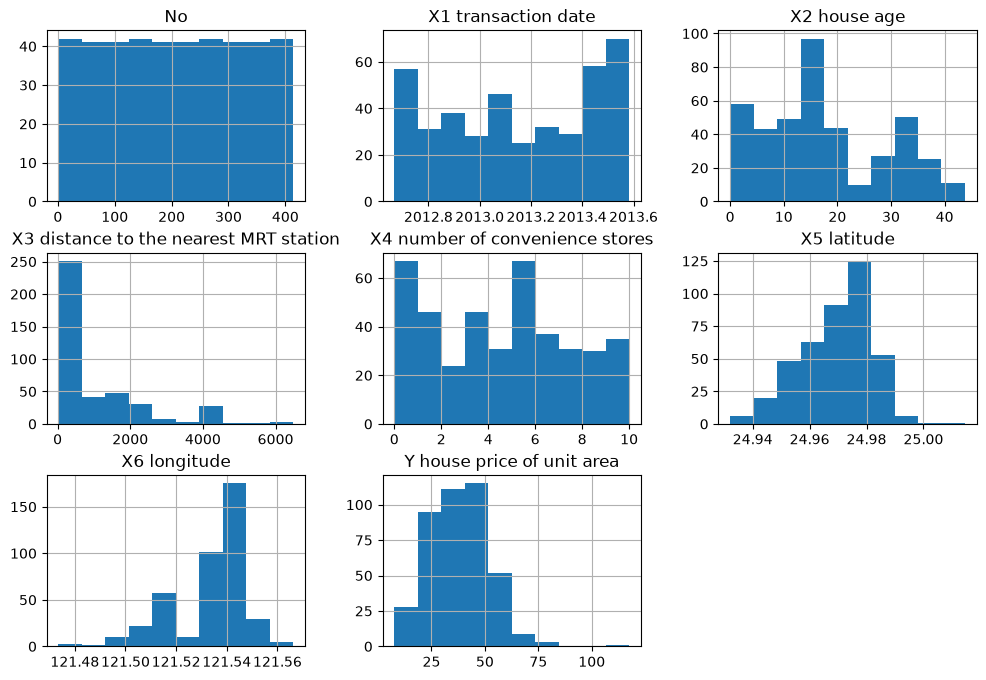

In [2]:
df.info()
df.describe()
df.hist(figsize=(12,8)); plt.show()

## 3. Data Preparation

Machine learning models typically perform better when data preparation is handled carefully.

Standardization is applied because several variables are measured on very different scales. This is particularly important for logistic regression and useful when comparing coefficient magnitudes.

For the classification task, a binary target variable is created using the mean training-set price as the decision threshold.

In [3]:
from sklearn.preprocessing import StandardScaler
X=df.drop(columns=['Y house price of unit area'])
y=df['Y house price of unit area']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
threshold=y_train.mean()
y_train_bin=(y_train>threshold).astype(int)
y_test_bin=(y_test>threshold).astype(int)

## 4. Modeling
### Linear Regression

Linear regression is used to predict the continuous house-price variable. The model estimates a weighted coefficient for each predictor. Because standardized features are used, the coefficient magnitudes can be compared directly to assess relative importance.

The code below trains the model and presents the learned coefficients.

In [4]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_train_scaled,y_train)
lin_pred=lin_reg.predict(X_test_scaled)
pd.DataFrame({'Feature':X.columns,'Coefficient':lin_reg.coef_}).sort_values('Coefficient',key=np.abs,ascending=False)

,Feature,Coefficient
3,X3 distance to the nearest MRT station,-5.855992
4,X4 number of convenience stores,3.188552
2,X2 house age,-3.029177
5,X5 latitude,2.817783
1,X1 transaction date,1.520267
0,No,-0.658369
6,X6 longitude,-0.450472


### Logistic Regression

Logistic regression models the probability that a property belongs to the higher-price category. The output is a probability value between 0 and 1, which is then converted into a class prediction.

The resulting coefficients provide insight into which features increase or decrease the likelihood of a property being above the average price level.

In [5]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled,y_train_bin)
log_pred=log_reg.predict(X_test_scaled)
log_prob=log_reg.predict_proba(X_test_scaled)[:,1]

## 5. Evaluation
### Linear Regression

Model performance is evaluated using three common regression metrics:

- **MAE**: average prediction error in original price units.
- **RMSE**: penalizes larger prediction errors more heavily.
- **R²**: proportion of variance explained by the model.

Higher R² and lower error values indicate better predictive performance.

In [6]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print('MAE',mean_absolute_error(y_test,lin_pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,lin_pred)))
print('R2',r2_score(y_test,lin_pred))

MAE 5.418035098628985
RMSE 7.389313951469142
R2 0.6745228670350909


### Logistic Regression

The classifier is evaluated using accuracy, precision, recall, F1-score and ROC-AUC. These metrics provide complementary perspectives on classification quality and class separation capability.

A strong model should achieve consistently high values across several metrics rather than performing well on only one metric.

In [7]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
print('Accuracy',accuracy_score(y_test_bin,log_pred))
print('Precision',precision_score(y_test_bin,log_pred))
print('Recall',recall_score(y_test_bin,log_pred))
print('F1',f1_score(y_test_bin,log_pred))
print('ROC-AUC',roc_auc_score(y_test_bin,log_prob))

Accuracy 0.8313253012048193
Precision 0.7441860465116279
Recall 0.9142857142857143
F1 0.8205128205128205
ROC-AUC 0.9202380952380952


## Interpretation and Conclusions

After executing all cells, the learned coefficients and validation metrics should be examined carefully. Expected observations for this dataset include:

- Distance to the nearest MRT station is typically among the strongest predictors, with shorter distances generally associated with higher property prices.
- House age often has a negative effect, indicating that older properties tend to be less expensive.
- Geographic location variables (latitude and longitude) frequently contribute significantly because location is a major determinant of real-estate value.
- Variables with coefficients close to zero contribute relatively little predictive information.

### Impact of Standardization

Standardization is recommended in this study. While linear regression predictions may remain similar without scaling, standardized coefficients become directly comparable. Logistic regression is considerably more sensitive to feature scales, and standardization often improves numerical stability and interpretability.

### Overall Assessment

If the regression model achieves a reasonably high R² value and relatively low prediction error, we can conclude that the selected features contain substantial information about house prices. Similarly, a high classification accuracy and ROC-AUC would indicate that the feature set effectively separates lower-priced and higher-priced properties.

The final conclusions should reference the actual coefficient rankings and metric values obtained when the notebook is executed.

## 6. Deployment

Although this analysis is educational in nature, the resulting models could be integrated into a real-estate valuation workflow.

Before production deployment, additional validation should be conducted using newer data and alternative models.

The most important practical outcome is understanding which variables drive property prices and how reliably those prices can be predicted using available information.